# 1. Устанавливаем библиотеку PyTorch + поддержку GPU

In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


Проверим версию

In [1]:
import torch
print(torch.__version__)

2.9.0+cpu


Проверим наличие GPU (Pytorch не поддерживает GPU AMD на Windows)

In [2]:
print(torch.cuda.is_available())

False


Для того, чтобы переключиться на GPU, используем следующий код:

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# 2. Тензоры

Основной объект PyTorch — Tensor

Тензор можно рассматривать как обобщение:
- числа;
- вектора;
- матрицы;
- многомерных массивов

## 2.1. Подготовка данных

In [4]:
import numpy as np
import torch

Генерируем данные

In [96]:
x = np.linspace(0, 4, 100).reshape(-1,1)
y_true = x**2

Конвертируем numpy array в torch tensor

In [6]:
x_tensor = torch.from_numpy(x).type(torch.float)
y_tensor = torch.from_numpy(y_true).type(torch.float)

In [7]:
type(x_tensor)

torch.Tensor

In [8]:
type(y_tensor)

torch.Tensor

## 2.2. Атрибуты тензоров

In [23]:
print(f"Размер тензора x: {x_tensor.shape}")
print(f"Тип данных тензора x: {x_tensor.dtype}")
print(f"Устройство, на котором хранится тензор x: {x_tensor.device}")

Размер тензора x: torch.Size([100, 1])
Тип данных тензора x: torch.float32
Устройство, на котором хранится тензор x: cpu


In [24]:
print(f"Размер тензора y: {y_tensor.shape}")
print(f"Тип данных тензора y: {y_tensor.dtype}")
print(f"Устройство, на котором хранится тензор y: {y_tensor.device}")

Размер тензора y: torch.Size([100, 1])
Тип данных тензора y: torch.float32
Устройство, на котором хранится тензор y: cpu


Переместить тензор на выбранный девайс:

In [11]:
x_tensor = x_tensor.to(device)
print(f"Устройство, на котором хранится тензор x: {x_tensor.device}")

Устройство, на котором хранится тензор x: cpu


## 2.3. Специальные тензоры 

Нулевой тензор

In [22]:
x = torch.zeros(3, 4)

In [23]:
x

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Единичный тензор

In [14]:
x = torch.ones(3, 4)

In [15]:
x

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Случайный тензор

In [16]:
x = torch.rand(3, 4)

In [17]:
x

tensor([[0.9350, 0.0453, 0.3789, 0.2543],
        [0.9466, 0.6379, 0.6773, 0.7620],
        [0.8004, 0.8300, 0.3980, 0.3264]])

Нормальное распределение

In [18]:
x = torch.randn(3, 4)

In [19]:
x

tensor([[ 0.3129,  1.1448,  0.3301, -0.2512],
        [-0.0019,  0.8302,  0.0363,  1.5387],
        [ 0.3588, -0.4553, -1.2532,  0.2002]])

Диапазон значений

In [20]:
x = torch.arange(0, 10)

In [21]:
x

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## 2.4. Срезы тензоров (аналогично numpy)

In [24]:
tensor = torch.rand(4, 4)
print(f"Первая строка: {tensor[0]}")
print(f"Первый столбец: {tensor[:, 0]}")
print(f"Последний столбец: {tensor[:, -1]}")
tensor[:,1] = 0
print(tensor)

Первая строка: tensor([0.6358, 0.4713, 0.6673, 0.6926])
Первый столбец: tensor([0.6358, 0.0487, 0.3553, 0.5183])
Последний столбец: tensor([0.6926, 0.3939, 0.2887, 0.6185])
tensor([[0.6358, 0.0000, 0.6673, 0.6926],
        [0.0487, 0.0000, 0.8066, 0.3939],
        [0.3553, 0.0000, 0.1759, 0.2887],
        [0.5183, 0.0000, 0.2890, 0.6185]])


## 2.5. Трансформация в Numpy

In [25]:
t = torch.ones(5)
print(f"t: {t}")
print(f"тип данных: {type(t)}")

n = t.numpy()
print(f"n: {n}")
print(f"тип данных: {type(n)}")

t: tensor([1., 1., 1., 1., 1.])
тип данных: <class 'torch.Tensor'>
n: [1. 1. 1. 1. 1.]
тип данных: <class 'numpy.ndarray'>


# 3. Автоматическое дифференцирование

Одна из ключевых возможностей PyTorch

Рассмотрим функцию $ y = x^2 $

Производная $ \frac{dy}{dx} = 2x $

Создадим переменную

In [26]:
x = torch.tensor(3.0, requires_grad=True)

Рассчитаем

In [27]:
y = x ** 2
print(y)

tensor(9., grad_fn=<PowBackward0>)


Продифференцируем

In [28]:
y.backward()

Получаем значение производной в точке x = 3

In [29]:
print(x.grad)

tensor(6.)


Потому что $ \frac{dy}{dx} = 2x = 2\cdot 3 $



Процесс обучения нейросети в PyTorch:
1) Предсказаниe (forward propagation)
2) Функция ошибки (loss)
3) Градиент (backward propagation)
4) Изменение весов
5) Новое предсказание

# 4. Нейронная сеть

Соберем нейронную сеть из двух линейных слоев и одной функции активации ReLU между ними:

$\hat{y}_i = a \cdot h_i + c$

$ h_i = max(0, z_i) $

$ z_i = w \cdot x_i + b$

Для работы нейронной сети нам нужно знать 4 параметра: $w, b, a, c$

Целиком функция выглядит как: $\hat{y}_i = a \cdot max(0, w \cdot x_i + b) + c$

Незвестные параметры будем подбирать с помощью градиентного спуска, находя минимум функции потерь: $L(w, b, a, c) = \frac{1}{n} \sum_{i=1}^{n}{(\hat{y}_i - y_i)^2}$

Загружаем модуль работы с нейросетями

In [32]:
import torch.nn as nn

In [97]:
x = np.linspace(0, 4, 100).reshape(-1,1)
y_true = x**2
x_tensor = torch.from_numpy(x).type(torch.float)
y_tensor = torch.from_numpy(y_true).type(torch.float)

## 4.1. Скрытый линейный слой

### 4.1.1. Инициализуем линейный слой

In [33]:
# Фиксируем seed
torch.manual_seed(42)

In [34]:
linear_layer1 = nn.Linear(in_features = 1, out_features = 1, bias = True)

In [35]:
type(linear_layer1)

torch.nn.modules.linear.Linear

In [36]:
linear_layer1

Linear(in_features=1, out_features=1, bias=True)

### 4.1.2. Атрибуты линейного слоя

In [37]:
print("Веса входящего нейрона скрытого линейного слоя (w)")
linear_layer1.weight

Веса входящего нейрона скрытого линейного слоя (w)


Parameter containing:
tensor([[0.7645]], requires_grad=True)

In [38]:
print("Смещение скрытого линейного слоя (b)")
linear_layer1.bias

Смещение скрытого линейного слоя (b)


Parameter containing:
tensor([0.8300], requires_grad=True)

In [39]:
print(f"Исходная форма скрытого слоя: {linear_layer1.weight[0][0]} x + {linear_layer1.bias[0]}")

Исходная форма скрытого слоя: 0.7645385265350342 x + 0.8300079107284546


### 4.1.3. Применим линейный слой к входным данным

In [40]:
z = linear_layer1(x_tensor)

In [48]:
print(x_tensor[:10].t())

tensor([[0.0000, 0.0404, 0.0808, 0.1212, 0.1616, 0.2020, 0.2424, 0.2828, 0.3232,
         0.3636]])


In [47]:
# Посмотрим на результат в виде транспонированного вектора
print(z[:10].t())

tensor([[0.8300, 0.8609, 0.8918, 0.9227, 0.9536, 0.9845, 1.0154, 1.0462, 1.0771,
         1.1080]], grad_fn=<TBackward0>)


## 4.2. Функция активации

In [49]:
relu = nn.ReLU()

Применим ReLU к скрытому слою

In [50]:
h = relu(z)

In [51]:
# Посмотрим на результат в виде транспонированного вектора
print(h[:10].t())

tensor([[0.8300, 0.8609, 0.8918, 0.9227, 0.9536, 0.9845, 1.0154, 1.0462, 1.0771,
         1.1080]], grad_fn=<TBackward0>)


## 4.3. Финальный линейный слой

### 4.3.1. Инициализуем линейный слой

In [52]:
linear_layer2 = nn.Linear(in_features = 1, out_features = 1, bias = True)

In [53]:
print("Веса входящих нейронов выходящего слоя (a)")
linear_layer2.weight

Веса входящих нейронов выходящего слоя (a)


Parameter containing:
tensor([[-0.2343]], requires_grad=True)

In [54]:
print("Смещение выходящего линейного слоя (c)")
linear_layer2.bias

Смещение выходящего линейного слоя (c)


Parameter containing:
tensor([0.9186], requires_grad=True)

In [59]:
print(f"Исходная форма выходящего слоя: {linear_layer2.weight[0][0]} h + {linear_layer2.bias[0]}")

Исходная форма выходящего слоя: -0.23427248001098633 h + 0.9186112880706787


### 4.3.2. Применим линейный слой к данным после функции ReLU

In [56]:
y_pred = linear_layer2(h)

In [58]:
# Посмотрим на результат в виде транспонированного вектора
print(y_pred[:10].t())

tensor([[0.7242, 0.7169, 0.7097, 0.7025, 0.6952, 0.6880, 0.6807, 0.6735, 0.6663,
         0.6590]], grad_fn=<TBackward0>)


# 5. Градиенты

## 5.1. Инициализуем функцию потерь

In [60]:
loss_fn = nn.MSELoss()

## 5.2. Считаем значение loss для первого шага

In [61]:
loss = loss_fn(y_pred, y_tensor)

In [62]:
loss

tensor(50.1802, grad_fn=<MseLossBackward0>)

In [63]:
print("Градиент для y_pred:", y_pred.grad_fn)
print("Градиент для функции потерь: ", loss.grad_fn)

Градиент для y_pred: <AddmmBackward0 object at 0x00000229364CA170>
Градиент для функции потерь:  <MseLossBackward0 object at 0x00000229364CA170>


## 5.3. Смотрим, есть ли рассчитанный градиент у скрытого слоя

In [64]:
linear_layer1.weight.grad

## 5.4. Обратный проход: вычисление градиентов

In [65]:
loss.backward()

In [66]:
linear_layer1.weight.grad

tensor([[7.3437]])

In [67]:
print("Градиент весов входящих нейронов скрытого линейного слоя (w)")
print(linear_layer1.weight.grad)

print("Градиент смещения скрытого линейного слоя (b)")
print(linear_layer1.bias.grad)

print("Градиент весов входящих нейронов выходящего слоя (a)")
print(linear_layer2.weight.grad)

print("Градиент смещения выходящего линейного слоя (c)")
print(linear_layer2.bias.grad)

Градиент весов входящих нейронов скрытого линейного слоя (w)
tensor([[7.3437]])
Градиент смещения скрытого линейного слоя (b)
tensor([2.3401])
Градиент весов входящих нейронов выходящего слоя (a)
tensor([[-32.2564]])
Градиент смещения выходящего линейного слоя (c)
tensor([-9.9887])


In [68]:
y_pred.numpy()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

## 5.5. Отключение сохранения градиента

In [69]:
print(y_pred.requires_grad)

True


In [70]:
with torch.no_grad():
    z = linear_layer1(x_tensor)
    h = relu(z)
    y_pred = linear_layer2(h)
print(y_pred.requires_grad)

False


In [72]:
print(y_pred.numpy()[0:10].T)

[[0.7241633  0.71692646 0.70968974 0.7024529  0.6952162  0.68797934
  0.6807426  0.6735058  0.666269   0.6590322 ]]


# 6. Оптимизация

Соберем все шаги, которые были сделаны ранее

In [73]:
n_neurons = 1

torch.manual_seed(42)
linear_layer1 = nn.Linear(in_features = 1, out_features = n_neurons, bias = True)
linear_layer2 = nn.Linear(in_features = n_neurons, out_features = 1, bias = True)
relu = nn.ReLU()

z = linear_layer1(x_tensor)
h = relu(z)
y_pred = linear_layer2(h)

loss_fn = nn.MSELoss()
loss = loss_fn(y_pred, y_tensor)

Смотрим на исходные параметры модели

In [74]:
print("Вес входящих нейронов скрытого линейного слоя")
print(linear_layer1.weight)

print("Смещение скрытого линейного слоя")
print(linear_layer1.bias)

print("Вес входящих нейронов выходящего слоя")
print(linear_layer2.weight)

print("Смещение выходящего линейного слоя")
print(linear_layer2.bias)

Вес входящих нейронов скрытого линейного слоя
Parameter containing:
tensor([[0.7645]], requires_grad=True)
Смещение скрытого линейного слоя
Parameter containing:
tensor([0.8300], requires_grad=True)
Вес входящих нейронов выходящего слоя
Parameter containing:
tensor([[-0.2343]], requires_grad=True)
Смещение выходящего линейного слоя
Parameter containing:
tensor([0.9186], requires_grad=True)


Достаем параметры, которые должны оптимизироваться

In [75]:
linear_layer1.parameters()

<generator object Module.parameters at 0x000002295011DE00>

In [76]:
parameters = list(linear_layer1.parameters())+ list(linear_layer2.parameters())

In [77]:
parameters

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True),
 Parameter containing:
 tensor([[-0.2343]], requires_grad=True),
 Parameter containing:
 tensor([0.9186], requires_grad=True)]

Инициализуем оптимизатор

In [78]:
learning_rate = 0.001
optimizer = torch.optim.SGD(parameters, lr = learning_rate)

Обнуляем рассчитанные градиенты

In [79]:
optimizer.zero_grad()

Проверим, что градиенты обнулились

In [80]:
linear_layer1.weight.grad

Обратное распространение ошибки: считаем градиенты

In [81]:
loss.backward()

Обновление параметров

Эквиваленто шагу 


```Python
w -= lr * dL_dw
b -= lr * dL_db
a -= lr * dL_da
c -= lr * dL_dc
```

из предыдущего занятия    

In [82]:
optimizer.step()

Смотрим на новые параметры

In [83]:
print("Вес входящих нейронов скрытого линейного слоя")
print(linear_layer1.weight)

print("Смещение скрытого линейного слоя")
print(linear_layer1.bias)

print("Вес входящих нейронов выходящего слоя")
print(linear_layer2.weight)

print("Смещение выходящего линейного слоя")
print(linear_layer2.bias)

Вес входящих нейронов скрытого линейного слоя
Parameter containing:
tensor([[0.7572]], requires_grad=True)
Смещение скрытого линейного слоя
Parameter containing:
tensor([0.8277], requires_grad=True)
Вес входящих нейронов выходящего слоя
Parameter containing:
tensor([[-0.2020]], requires_grad=True)
Смещение выходящего линейного слоя
Parameter containing:
tensor([0.9286], requires_grad=True)


# 7. Собираем в цикл

In [84]:
# Задаем константы
n_neurons = 1
epochs = 10000
learning_rate = 0.001
loss_history = []

# Собираем нейросеть
torch.manual_seed(42)
linear_layer1 = nn.Linear(in_features = 1, out_features = n_neurons, bias = True)
linear_layer2 = nn.Linear(in_features = n_neurons, out_features = 1, bias = True)
relu = nn.ReLU()

# Инициализуем функцию потерь и оптимизатор
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(list(linear_layer1.parameters())+ list(linear_layer2.parameters()), lr = learning_rate)

In [85]:
for epoch in range(epochs):
  # Прямой проход
  z = linear_layer1(x_tensor)
  h = relu(z)
  y_pred = linear_layer2(h)

  # Расчет функции потерь
  loss = loss_fn(y_pred, y_tensor)
  loss_history.append(loss)

  # Обратный проход
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Выводим информацию о процессе обучения для каждой 200й эпохи
  if epoch % 500 == 0:
      w = linear_layer1.weight[0,0]
      b = linear_layer1.bias[0]
      a = linear_layer2.weight[0,0]
      c = linear_layer2.bias[0]
      print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f} | a: {a:.4f} | c: {c:.4f}")

Epoch    0 | Loss: 50.180176 | w: 0.7572 | b: 0.8277 | a: -0.2020 | c: 0.9286
Epoch  500 | Loss: 3.775046 | w: 1.8732 | b: -0.0983 | a: 1.5240 | c: 0.5093
Epoch 1000 | Loss: 1.541677 | w: 1.9565 | b: -0.9338 | a: 1.8714 | c: 0.0015
Epoch 1500 | Loss: 0.809505 | w: 1.9559 | b: -1.4172 | a: 2.1532 | c: -0.2007
Epoch 2000 | Loss: 0.573814 | w: 1.9459 | b: -1.6973 | a: 2.3387 | c: -0.2356
Epoch 2500 | Loss: 0.480564 | w: 1.9349 | b: -1.8690 | a: 2.4575 | c: -0.1921
Epoch 3000 | Loss: 0.427564 | w: 1.9234 | b: -1.9861 | a: 2.5390 | c: -0.1165
Epoch 3500 | Loss: 0.391735 | w: 1.9132 | b: -2.0705 | a: 2.5979 | c: -0.0322
Epoch 4000 | Loss: 0.364683 | w: 1.9038 | b: -2.1367 | a: 2.6442 | c: 0.0503
Epoch 4500 | Loss: 0.343900 | w: 1.8955 | b: -2.1912 | a: 2.6826 | c: 0.1265
Epoch 5000 | Loss: 0.328661 | w: 1.8882 | b: -2.2355 | a: 2.7139 | c: 0.1940
Epoch 5500 | Loss: 0.317591 | w: 1.8828 | b: -2.2714 | a: 2.7397 | c: 0.2532
Epoch 6000 | Loss: 0.308587 | w: 1.8774 | b: -2.3052 | a: 2.7641 | c: 

In [86]:
w = linear_layer1.weight[0,0]
b = linear_layer1.bias[0]
a = linear_layer2.weight[0,0]
c = linear_layer2.bias[0]
print("Веса после обучения")
print(f"w: {w:.4f} | b: {b:.4f} | a: {a:.4f} | c: {c:.4f}")

Веса после обучения
w: 1.8584 | b: -2.4329 | a: 2.8591 | c: 0.5136


Применяем обученную нейронную сеть к данным

In [87]:
with torch.no_grad():
  z = linear_layer1(x_tensor)
  h = relu(z)
  y_pred = linear_layer2(h)

print(y_pred.requires_grad)

False


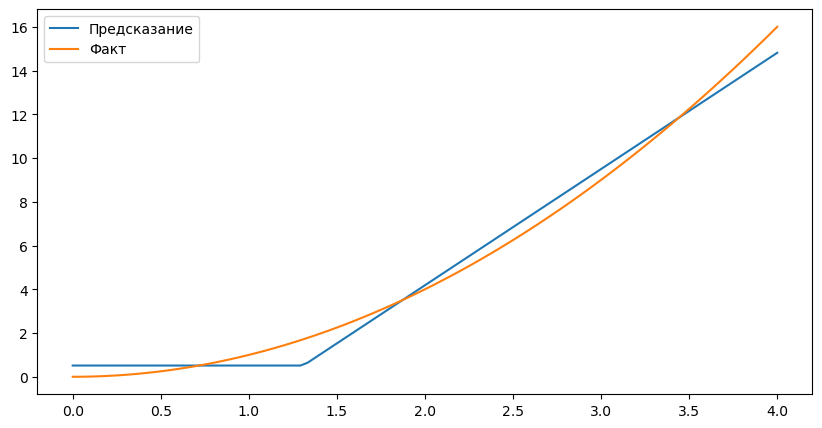

In [98]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()

# 8. Попробуем сделать в скрытом слое 5 нейронов

In [99]:
# Задаем константы
n_neurons = 5
epochs = 10000
learning_rate = 0.001
loss_history = []

# Собираем нейросеть
torch.manual_seed(42)
linear_layer1 = nn.Linear(in_features = 1, out_features = n_neurons, bias = True)
linear_layer2 = nn.Linear(in_features = n_neurons, out_features = 1, bias = True)
relu = nn.ReLU()

# Инициализуем функцию потерь и оптимизатор
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(list(linear_layer1.parameters())+ list(linear_layer2.parameters()), lr = learning_rate)

In [100]:
for epoch in range(epochs):
  # Прямой проход
  z = linear_layer1(x_tensor)
  h = relu(z)
  y_pred = linear_layer2(h)

  # Расчет функции потерь
  loss = loss_fn(y_pred, y_tensor)
  loss_history.append(loss)

  # Обратный проход
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Выводим информацию о процессе обучения для каждой 500й эпохи
  if epoch % 500 == 0:
    print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

Epoch    0 | Loss: 38.960335
Epoch  500 | Loss: 1.926892
Epoch 1000 | Loss: 0.939088
Epoch 1500 | Loss: 0.591061
Epoch 2000 | Loss: 0.411137
Epoch 2500 | Loss: 0.291242
Epoch 3000 | Loss: 0.210904
Epoch 3500 | Loss: 0.157586
Epoch 4000 | Loss: 0.121188
Epoch 4500 | Loss: 0.095707
Epoch 5000 | Loss: 0.077729
Epoch 5500 | Loss: 0.064677
Epoch 6000 | Loss: 0.055175
Epoch 6500 | Loss: 0.048155
Epoch 7000 | Loss: 0.042713
Epoch 7500 | Loss: 0.038541
Epoch 8000 | Loss: 0.035291
Epoch 8500 | Loss: 0.032534
Epoch 9000 | Loss: 0.030369
Epoch 9500 | Loss: 0.028455


In [100]:
print("Вес входящих нейронов скрытого линейного слоя")
print(linear_layer1.weight.T)

print("Смещение скрытого линейного слоя")
print(linear_layer1.bias)

print("Вес входящих нейронов выходящего слоя")
print(linear_layer2.weight)

print("Смещение выходящего линейного слоя")
print(linear_layer2.bias)

Вес входящих нейронов скрытого линейного слоя
tensor([[ 1.3393,  0.9975, -0.2989,  1.4499, -0.2191]],
       grad_fn=<PermuteBackward0>)
Смещение скрытого линейного слоя
Parameter containing:
tensor([-1.5584, -2.4210,  0.6374,  0.3981, -0.7336], requires_grad=True)
Вес входящих нейронов выходящего слоя
Parameter containing:
tensor([[1.9371, 2.4376, 0.4526, 0.8099, 0.2156]], requires_grad=True)
Смещение выходящего линейного слоя
Parameter containing:
tensor([-0.7692], requires_grad=True)


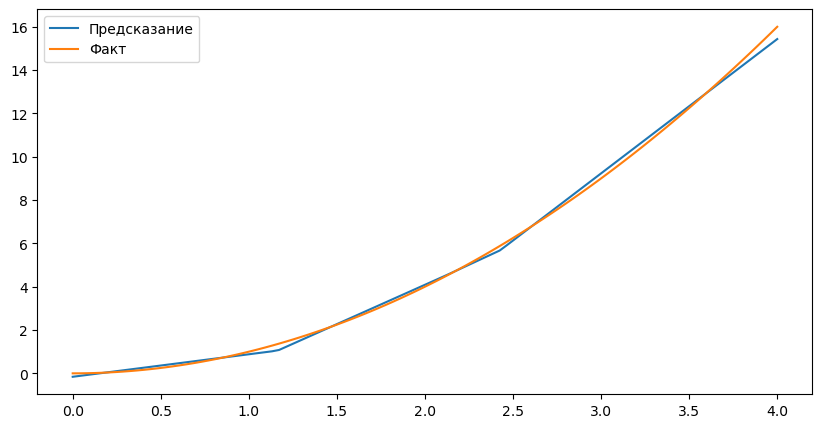

In [101]:
with torch.no_grad():
  z = linear_layer1(x_tensor)
  h = relu(z)
  y_pred = linear_layer2(h)

fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()

# 9. Пишем класс для модели нейросети

nn.Sequential позволяет последовательно объединять слои

In [104]:
class SimpleNN(nn.Module):
    torch.manual_seed(42)
    def __init__(self, n_neurons):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features = 1, out_features = n_neurons, bias=True),
            nn.ReLU(),
            nn.Linear(in_features = n_neurons, out_features = 1, bias=True)
        ) 
    def forward(self, x):
        return self.network(x)

In [105]:
n_neurons = 10
learning_rate = 0.001
epochs = 10000
loss_history = []

# Инициализуем модель
model = SimpleNN(n_neurons = n_neurons)

# Инициализуем функцию потерь и оптимизатор
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

In [106]:
for epoch in range(epochs):
  # Прямой проход
  model.train()
  y_pred = model(x_tensor)

  # Расчет функции потерь
  loss = loss_fn(y_pred, y_tensor)
  loss_history.append(loss)

  # Обратный проход
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 500 == 0:
    print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

Epoch    0 | Loss: 52.541595
Epoch  500 | Loss: 1.635907
Epoch 1000 | Loss: 1.048468
Epoch 1500 | Loss: 0.837441
Epoch 2000 | Loss: 0.650256
Epoch 2500 | Loss: 0.498647
Epoch 3000 | Loss: 0.378165
Epoch 3500 | Loss: 0.282695
Epoch 4000 | Loss: 0.209918
Epoch 4500 | Loss: 0.157408
Epoch 5000 | Loss: 0.120753
Epoch 5500 | Loss: 0.095558
Epoch 6000 | Loss: 0.077989
Epoch 6500 | Loss: 0.065473
Epoch 7000 | Loss: 0.056206
Epoch 7500 | Loss: 0.049188
Epoch 8000 | Loss: 0.043608
Epoch 8500 | Loss: 0.039177
Epoch 9000 | Loss: 0.035668
Epoch 9500 | Loss: 0.032754


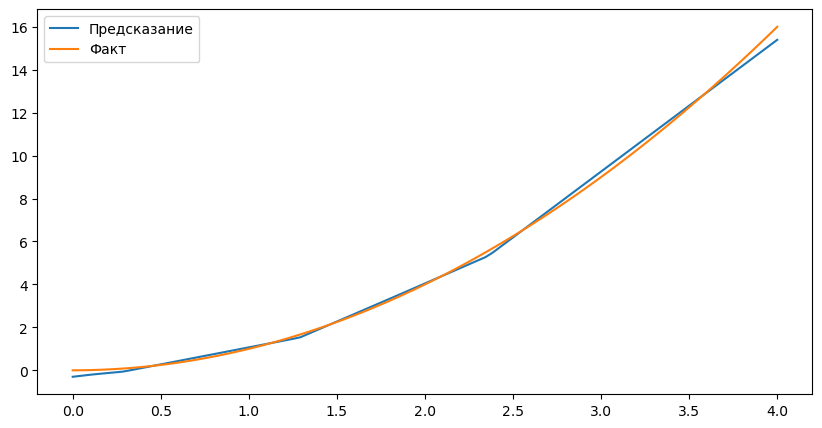

In [107]:
with torch.no_grad():
    model.eval()
    y_pred = model(x_tensor)

fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()

# 10. Добавим в нейросеть второй скрытый слой

In [108]:
class TwoLayerNN(nn.Module):
    torch.manual_seed(42)
    def __init__(self, n_neurons):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features = 1, out_features = n_neurons, bias=True),
            nn.ReLU(),
            nn.Linear(in_features = n_neurons, out_features = n_neurons, bias=True),
            nn.ReLU(),
            nn.Linear(in_features = n_neurons, out_features = 1, bias=True)
        )
    
    def forward(self, x):
        return self.network(x)

In [110]:
n_neurons = 5
learning_rate = 0.01
epochs = 10000
loss_history = []

# Инициализуем модель
model = TwoLayerNN(n_neurons = n_neurons)

# Инициализуем функцию потерь и оптимизатор
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

In [111]:
for epoch in range(epochs):
  # Прямой проход
  model.train()
  y_pred = model(x_tensor)

  # Расчет функции потерь
  loss = loss_fn(y_pred, y_tensor)
  loss_history.append(loss)

  # Обратный проход
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 500 == 0:
    print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

Epoch    0 | Loss: 51.259201
Epoch  500 | Loss: 0.602800
Epoch 1000 | Loss: 0.229020
Epoch 1500 | Loss: 0.122602
Epoch 2000 | Loss: 0.075273
Epoch 2500 | Loss: 0.060101
Epoch 3000 | Loss: 0.044130
Epoch 3500 | Loss: 0.044364
Epoch 4000 | Loss: 0.035446
Epoch 4500 | Loss: 0.029903
Epoch 5000 | Loss: 0.025648
Epoch 5500 | Loss: 0.023928
Epoch 6000 | Loss: 0.023220
Epoch 6500 | Loss: 0.022523
Epoch 7000 | Loss: 0.019898
Epoch 7500 | Loss: 0.018541
Epoch 8000 | Loss: 0.017376
Epoch 8500 | Loss: 0.016322
Epoch 9000 | Loss: 0.014833
Epoch 9500 | Loss: 0.013712


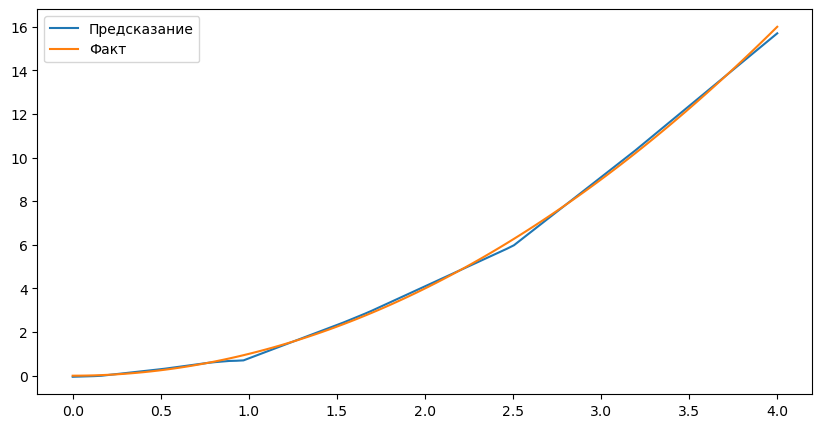

In [112]:
model.eval()
with torch.no_grad():
    y_pred = model(x_tensor)

fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()

# 11. Итоговый пайплайн обучения и предсказаний полносвязной нейронной сети 

In [116]:
# 1. Выбор девайса
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Инициализация модели

class MyNN(nn.Module):
    torch.manual_seed(42)
    def __init__(self, n_neurons):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features = 1, out_features = n_neurons, bias=True),
            nn.ReLU(),
            nn.Linear(in_features = n_neurons, out_features = n_neurons, bias=True),
            nn.ReLU(),
            nn.Linear(in_features = n_neurons, out_features = 1, bias=True)
        )
    
    def forward(self, x):
        return self.network(x)

n_neurons = 10
model = MyNN(n_neurons).to(device)

# 3. Фукция потерь
criterion = nn.MSELoss()

# 4. Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10000
# 5. Обучение (можно упаковать в функцию)
for epoch in range(epochs):
    # Прямой проход
    x_tensor = x_tensor.to(device)
    y_tensor = y_tensor.to(device)
    
    model.train()
    y_pred = model(x_tensor)
    
    # Расчет функции потерь
    loss = loss_fn(y_pred, y_tensor)
    loss_history.append(loss)
    
    # Обратный проход
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

# 6. Получение предсказаний
model.eval()
with torch.no_grad():
  y_pred = model(x_tensor)

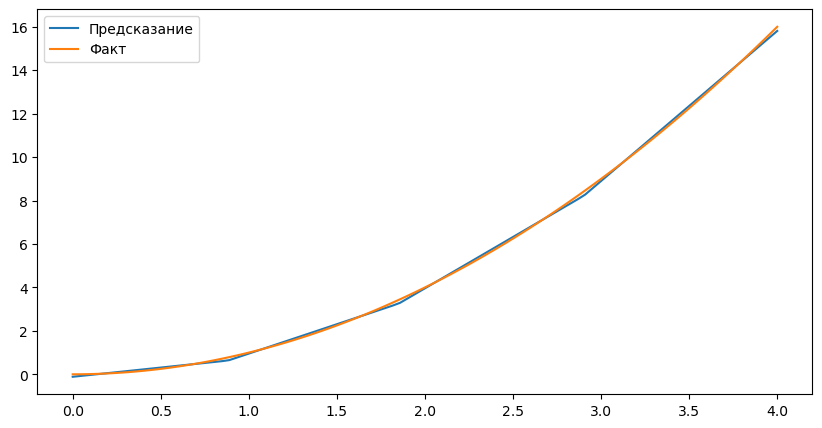

In [117]:
fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()